# Lung atlas: does a single source help `multi_source_pooled`?

Standalone study, separate from `aggregate_and_plot_paper.ipynb` /
`aggregate_and_plot_new_pooled.ipynb`: for the `multi_source_pooled` estimator
only (the pure source-projection method -- no target signal used to estimate
the projection direction), compares **target-only** (no source at all) against
**multi_source_pooled with all 3 other batches pooled** against
**multi_source_pooled with each individual other batch as the sole source** --
i.e. is transferring from any single source ever better than not transferring
at all, or than pooling every available source together?

This notebook does not touch `pooled_concat`/`target_source_pooled` ("the
Pooled method") at all, so there's no old/new-pooled split needed here.

Reads `results_0.5_alpha/raw/*.csv` (written by `run_lung_atlas_comparison.py`).
X-axis groups are labeled by **patient ID**, not the internal `Dropseq_N` batch
name -- the mapping (confirmed directly from `lung_atlas_hvg_lognorm.h5ad`'s own
`obs['patient']` column, not inferred) is `Dropseq_1=ASK428`, `Dropseq_2=ASK440`,
`Dropseq_3=ASK452`, `Dropseq_4=ASK454`, matching arXiv:2607.25031 Section 6.

Outputs land in `results_0.5_alpha/single_source/`: `single_source_sensitivity.csv`,
`single_source_sensitivity_misclustering.pdf`, `single_source_sensitivity_ari.pdf`,
`single_source_sensitivity_table.tex`.

In [1]:
import glob, os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import common

## Load and filter to `target_only` + `multi_source_pooled`

Reads every `results_0.5_alpha/raw/*.csv`, keeps only rows for these two
methods, and checks completeness against the expected grid restricted to them
(`target_only`: 1 row/target, no source; `multi_source_pooled`: 4 rows/target
-- "all" plus one per individual other batch).

In [2]:
RESULTS_DIR = "results_0.5_alpha"
RAW_DIR = os.path.join(RESULTS_DIR, "raw")
OUT_DIR = os.path.join(RESULTS_DIR, "single_source")
os.makedirs(OUT_DIR, exist_ok=True)

# Confirmed directly from lung_atlas_hvg_lognorm.h5ad's own obs['batch'] /
# obs['patient'] columns (h5py cross-tab), not inferred from cell counts --
# matches arXiv:2607.25031 Section 6's patient IDs.
BATCH_TO_PATIENT = {
    "Dropseq_1": "ASK428",
    "Dropseq_2": "ASK440",
    "Dropseq_3": "ASK452",
    "Dropseq_4": "ASK454",
}
PATIENT_ORDER = [BATCH_TO_PATIENT[b] for b in common.BATCHES]

raw_paths = sorted(glob.glob(os.path.join(RAW_DIR, "*.csv")))
print(f"Found {len(raw_paths)} raw result files in {RAW_DIR}")
assert raw_paths, f"No CSVs found in {RAW_DIR}"

INCLUDED_METHODS = ["target_only", "multi_source_pooled"]


def expected_grid():
    """Mirrors run_lung_atlas_comparison.py's task_grid(), restricted to
    target_only + multi_source_pooled, as (target, method, source) triples."""
    grid = set()
    for target in common.BATCHES:
        others = [b for b in common.BATCHES if b != target]
        grid.add((target, "target_only", "none"))
        grid.add((target, "multi_source_pooled", "all"))
        for src in others:
            grid.add((target, "multi_source_pooled", src))
    return grid


expected = expected_grid()
found = set()
rows = []
for path in raw_paths:
    row = pd.read_csv(path).iloc[0]
    if row["method"] not in INCLUDED_METHODS:
        continue
    rows.append(row.to_dict())
    found.add((row["target"], row["method"], row["source"]))

missing = expected - found
if missing:
    print(f"WARNING: {len(missing)}/{len(expected)} (target, method, source) results missing from {RAW_DIR}:")
    for target, method, source in sorted(missing):
        print(f"  {target}, {method}, {source}")
else:
    print(f"All {len(expected)} (target, method, source) combinations present")

results = pd.DataFrame(rows)
results["target_patient"] = results["target"].map(BATCH_TO_PATIENT)
results["source_patient"] = results["source"].map(BATCH_TO_PATIENT)  # NaN for "all"/"none", expected

combined_path = os.path.join(OUT_DIR, "single_source_sensitivity.csv")
results.to_csv(combined_path, index=False)
print(f"Wrote {combined_path}")
results

Found 80 raw result files in results_0.5_alpha/raw


All 20 (target, method, source) combinations present
Wrote results_0.5_alpha/single_source/single_source_sensitivity.csv


,target,method,source,elapsed_sec,misclustering,ari,v_measure,target_patient,source_patient
0,Dropseq_1,multi_source_pooled,Dropseq_2,121.195837,0.535748,0.385344,0.648809,ASK428,ASK440
1,Dropseq_1,multi_source_pooled,Dropseq_3,57.466810,0.479504,0.436872,0.661298,ASK428,ASK452
2,Dropseq_1,multi_source_pooled,Dropseq_4,39.709415,0.531935,0.383023,0.606360,ASK428,ASK454
3,Dropseq_1,multi_source_pooled,all,265.920643,0.507150,0.431597,0.653114,ASK428,NaN
4,Dropseq_1,target_only,none,55.677046,0.459009,0.455743,0.681196,ASK428,NaN
5,Dropseq_2,multi_source_pooled,Dropseq_1,46.063302,0.533459,0.344955,0.601415,ASK440,ASK428
6,Dropseq_2,multi_source_pooled,Dropseq_3,62.351900,0.534087,0.346089,0.608752,ASK440,ASK452
7,Dropseq_2,multi_source_pooled,Dropseq_4,39.502702,0.534402,0.333182,0.563217,ASK440,ASK454
8,Dropseq_2,multi_source_pooled,all,163.600241,0.533773,0.346199,0.604017,ASK440,NaN
9,Dropseq_2,target_only,none,161.325589,0.508954,0.363136,0.618400,ASK440,NaN


## Figure: target-only vs. all-sources-pooled vs. each single source

Grouped bar chart -- one group per target **patient**, up to 5 bars per group:
**Target-only** (baseline, blue), **All sources pooled** (multi_source_pooled
using every other batch, orange), and one **Single source** bar (aqua) per
individual other patient. All source-identifying bars are the *same* aqua --
which specific patient supplied that source is given by a direct text label
under each bar, not by a distinct hue per patient (a fixed patient-to-hue
mapping would put a different, non-adjacent-validated pair of hues next to
each other in every panel, since which patient is "missing" as a possible
source changes per target group). Blue/orange/aqua are this repo's validated
palette's first three categorical slots, which clear every CVD/contrast check
for *any* pairing or order (not just adjacent), so this is safe regardless of
which 3-of-4 patients end up in a given group.

Wrote results_0.5_alpha/single_source/single_source_sensitivity_misclustering.pdf


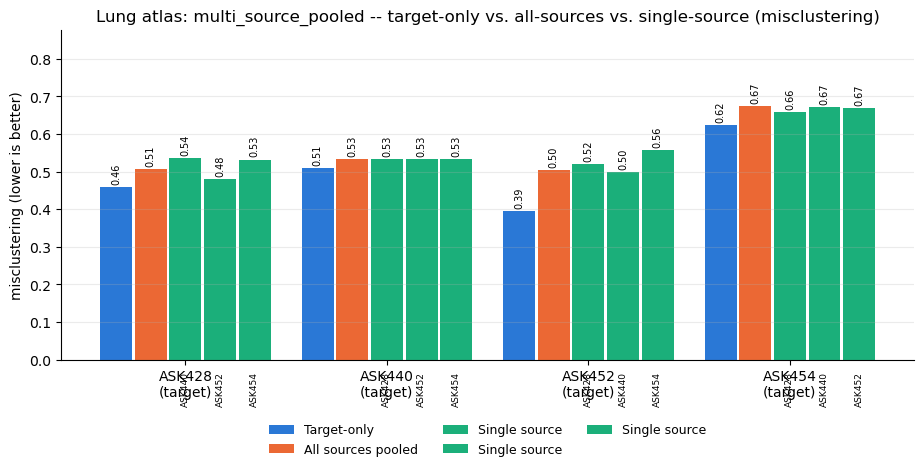

Wrote results_0.5_alpha/single_source/single_source_sensitivity_ari.pdf


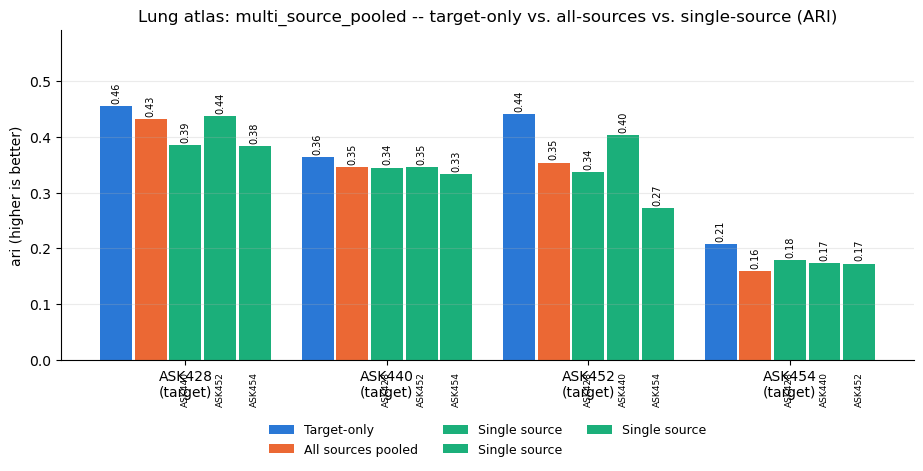

In [3]:
COLOR_TARGET_ONLY = "#2a78d6"    # slot 1 blue
COLOR_ALL_SOURCES = "#eb6834"    # slot 2 orange
COLOR_SINGLE_SOURCE = "#1baf7a"  # slot 3 aqua


def plot_single_source_chart(metric: str, higher_is_better: bool, out_name: str):
    fig, ax = plt.subplots(figsize=(11, 5.5))

    n_bars_max = 5  # Target-only + All-sources + up to 3 single-source
    group_width = 0.86
    bar_width = group_width / n_bars_max
    group_centers = np.arange(len(common.BATCHES))

    for gi, target in enumerate(common.BATCHES):
        others = [b for b in common.BATCHES if b != target]  # 3 other batches for this target

        bar_specs = []  # (label_for_legend, color, value, under_label)
        baseline = results[(results["method"] == "target_only") & (results["target"] == target)][metric].iloc[0]
        bar_specs.append(("Target-only", COLOR_TARGET_ONLY, baseline, ""))

        all_val = results[(results["method"] == "multi_source_pooled") & (results["target"] == target)
                           & (results["source"] == "all")][metric].iloc[0]
        bar_specs.append(("All sources pooled", COLOR_ALL_SOURCES, all_val, ""))

        for src in others:
            src_val = results[(results["method"] == "multi_source_pooled") & (results["target"] == target)
                               & (results["source"] == src)][metric].iloc[0]
            bar_specs.append(("Single source", COLOR_SINGLE_SOURCE, src_val, BATCH_TO_PATIENT[src]))

        n_bars = len(bar_specs)
        offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * bar_width
        for (label, color, val, under_label), offset in zip(bar_specs, offsets):
            bar = ax.bar(group_centers[gi] + offset, val, bar_width * 0.92, color=color,
                          label=label if gi == 0 else None)  # dedupe legend via label=None on later groups
            ax.bar_label(bar, fmt="%.2f", padding=2, fontsize=7, rotation=90)
            if under_label:
                ax.text(group_centers[gi] + offset, -0.035, under_label, ha="center", va="top",
                        fontsize=6.5, rotation=90, transform=ax.get_xaxis_transform())

    ax.set_xticks(group_centers)
    ax.set_xticklabels([f"{BATCH_TO_PATIENT[b]}\n(target)" for b in common.BATCHES])
    ax.set_ylabel(f"{metric} (higher is better)" if higher_is_better else f"{metric} (lower is better)")
    metric_title = "ARI" if metric == "ari" else metric
    ax.set_title(f"Lung atlas: multi_source_pooled -- target-only vs. all-sources vs. single-source ({metric_title})")
    ymin = min(0.0, results[metric].min() * 1.1)
    ymax = results[metric].max()
    ax.set_ylim(ymin, ymax * 1.3 if not higher_is_better else min(ymax * 1.3, 1.05))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(frameon=False, fontsize=9, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.16))
    fig.subplots_adjust(bottom=0.28)

    fig_path = os.path.join(OUT_DIR, out_name)
    fig.savefig(fig_path, bbox_inches="tight")
    print(f"Wrote {fig_path}")
    plt.show()


plot_single_source_chart("misclustering", higher_is_better=False, out_name="single_source_sensitivity_misclustering.pdf")
plot_single_source_chart("ari", higher_is_better=True, out_name="single_source_sensitivity_ari.pdf")

## LaTeX table

Rows: Target-only, All sources pooled, Source=<each patient>. Columns: one
group per target patient, split into ARI / V-measure / $\mathcal{L}_{\mathrm{mult}}$
subcolumns (matching the main comparison tables' combined-table convention).
A `Source=<target's own patient>` cell is blank -- a patient is never its own
source. Best value per subcolumn bolded (ARI/V-measure: higher is better;
$\mathcal{L}_{\mathrm{mult}}$: lower is better) -- blank cells are excluded
from the "best" comparison.

In [4]:
SUBCOLS = [("ari", "ARI", "high"), ("v_measure", "V-measure", "high"),
           ("misclustering", "$\\mathcal{L}_{\\mathrm{mult}}$", "low")]
ROW_LABELS = ["Target-only", "All sources pooled"] + [f"Source={p}" for p in PATIENT_ORDER]


def row_value(row_label: str, target: str, metric: str):
    if row_label == "Target-only":
        sub = results[(results["method"] == "target_only") & (results["target"] == target)]
    elif row_label == "All sources pooled":
        sub = results[(results["method"] == "multi_source_pooled") & (results["target"] == target)
                       & (results["source"] == "all")]
    else:
        src_patient = row_label.split("=", 1)[1]
        src_batch = [b for b, p in BATCH_TO_PATIENT.items() if p == src_patient][0]
        sub = results[(results["method"] == "multi_source_pooled") & (results["target"] == target)
                       & (results["source"] == src_batch)]
    return sub[metric].iloc[0] if len(sub) else np.nan


def make_single_source_latex_table(caption: str = "", label: str = "") -> str:
    n_sub = len(SUBCOLS)
    lines = []
    lines.append("\\begin{table}[t]")
    lines.append("\\centering")
    lines.append("\\resizebox{\\textwidth}{!}{%")
    lines.append("\\begin{tabular}{l" + "ccc" * len(common.BATCHES) + "}")
    lines.append("\\toprule")

    header1 = [""]
    cmidrules = []
    col = 2
    for target in common.BATCHES:
        header1.append(f"\\multicolumn{{{n_sub}}}{{c}}{{{BATCH_TO_PATIENT[target]}}}")
        cmidrules.append(f"\\cmidrule(lr){{{col}-{col + n_sub - 1}}}")
        col += n_sub
    lines.append(" & ".join(header1) + " \\\\")
    lines.append(" ".join(cmidrules))

    header2 = [""] + [sub_label for _ in common.BATCHES for _, sub_label, _ in SUBCOLS]
    lines.append(" & ".join(header2) + " \\\\")
    lines.append("\\midrule")

    # Best-per-subcolumn, ignoring NaN (the "source == target" blank cells).
    best_per_col = {}
    for target in common.BATCHES:
        for metric, _, direction in SUBCOLS:
            vals = [row_value(rl, target, metric) for rl in ROW_LABELS]
            vals = [v for v in vals if not np.isnan(v)]
            best_per_col[(target, metric)] = (min(vals) if direction == "low" else max(vals)) if vals else None

    for row_label in ROW_LABELS:
        cells = []
        for target in common.BATCHES:
            for metric, _, direction in SUBCOLS:
                val = row_value(row_label, target, metric)
                if np.isnan(val):
                    cells.append("--")
                    continue
                cell = f"{val:.3f}"
                best = best_per_col[(target, metric)]
                if best is not None and np.isclose(val, best):
                    cell = f"\\textbf{{{cell}}}"
                cells.append(cell)
        lines.append(f"{row_label} & " + " & ".join(cells) + " \\\\")

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}%")
    lines.append("}")
    if caption:
        lines.append(f"\\caption{{{caption}}}")
    if label:
        lines.append(f"\\label{{{label}}}")
    lines.append("\\end{table}")
    return "\n".join(lines)


caption = ("multi\\_source\\_pooled: ARI, V-measure, and misclustering error ($\\mathcal{L}_{\\mathrm{mult}}$) "
           "on the lung atlas (13 fine-grained cell types, K=13), target-only vs. all-sources-pooled vs. each "
           "individual patient used as the sole source. A blank cell means that patient is the target itself.")
table_tex = make_single_source_latex_table(caption=caption, label="tab:lung_single_source")
print(table_tex)

table_path = os.path.join(OUT_DIR, "single_source_sensitivity_table.tex")
with open(table_path, "w") as f:
    f.write(table_tex)
    f.write("\n")
print(f"Wrote {table_path}")

\begin{table}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccccccccc}
\toprule
 & \multicolumn{3}{c}{ASK428} & \multicolumn{3}{c}{ASK440} & \multicolumn{3}{c}{ASK452} & \multicolumn{3}{c}{ASK454} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10} \cmidrule(lr){11-13}
 & ARI & V-measure & $\mathcal{L}_{\mathrm{mult}}$ & ARI & V-measure & $\mathcal{L}_{\mathrm{mult}}$ & ARI & V-measure & $\mathcal{L}_{\mathrm{mult}}$ & ARI & V-measure & $\mathcal{L}_{\mathrm{mult}}$ \\
\midrule
Target-only & \textbf{0.456} & \textbf{0.681} & \textbf{0.459} & \textbf{0.363} & \textbf{0.618} & \textbf{0.509} & \textbf{0.440} & \textbf{0.661} & \textbf{0.395} & \textbf{0.208} & \textbf{0.469} & \textbf{0.624} \\
All sources pooled & 0.432 & 0.653 & 0.507 & 0.346 & 0.604 & 0.534 & 0.354 & 0.606 & 0.504 & 0.159 & 0.418 & 0.675 \\
Source=ASK428 & -- & -- & -- & 0.345 & 0.601 & 0.533 & 0.337 & 0.601 & 0.521 & 0.179 & 0.440 & 0.658 \\
Source=ASK440 & 0.385 & 0.649 & 0.536 & -- & -- & -

Wrote results_0.5_alpha/single_source/single_source_sensitivity_table.tex
